Data loaded successfully! Shape: (101766, 8)

=== Dataset Overview ===
        age  time_in_hospital  num_lab_procedures  num_medications  \
0    [0-10)                 1                  41                1   
1   [10-20)                 3                  59               18   
2   [20-30)                 2                  11               13   
3   [30-40)                 2                  44               16   
4   [40-50)                 1                  51                8   
5   [50-60)                 3                  31               16   
6   [60-70)                 4                  70               21   
7   [70-80)                 5                  73               12   
8   [80-90)                13                  68               28   
9  [90-100)                12                  33               18   

   number_outpatient  number_emergency  number_inpatient  readmitted_flag  
0                  0                 0                 0                0  
1     

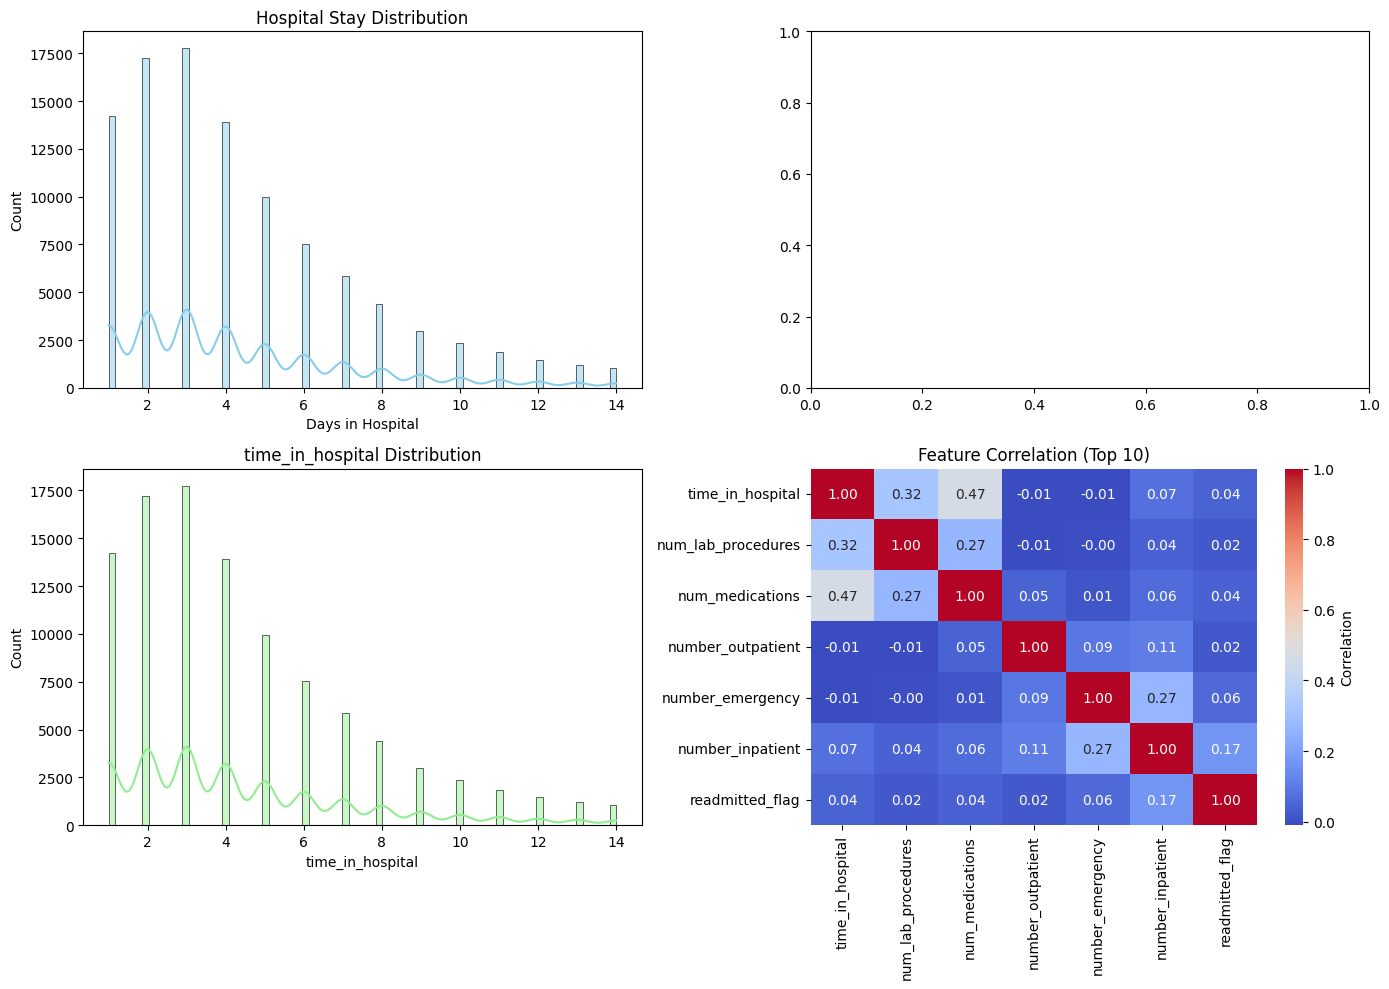


✓ Visualizations saved to ../data/processed/eda_visualizations.png


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
try:
    df = pd.read_csv("../data/processed/processed_data.csv")
    print(f"Data loaded successfully! Shape: {df.shape}")
except FileNotFoundError:
    print("Error: processed_data.csv not found. Check file path.")
    df = None

if df is not None:
    # Basic info
    print("\n=== Dataset Overview ===")
    print(df.head(10))
    print(f"\nData Types:\n{df.dtypes}")
    print(f"\nMissing Values:\n{df.isnull().sum()}")
    print(f"\nStatistical Summary:\n{df.describe()}")
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Hospital stay distribution
    if 'time_in_hospital' in df.columns:
        sns.histplot(df['time_in_hospital'], kde=True, ax=axes[0, 0], color='skyblue')
        axes[0, 0].set_title("Hospital Stay Distribution")
        axes[0, 0].set_xlabel("Days in Hospital")
    
    # Readmission distribution (if exists)
    if 'readmitted' in df.columns:
        df['readmitted'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
        axes[0, 1].set_title("Readmission Status")
        axes[0, 1].set_ylabel("Count")
    
    # Age distribution
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        first_numeric = numeric_cols[0]
        sns.histplot(df[first_numeric], kde=True, ax=axes[1, 0], color='lightgreen')
        axes[1, 0].set_title(f"{first_numeric} Distribution")
    
    # Correlation heatmap (top features only)
    numeric_df = df.select_dtypes(include=[np.number])
    if len(numeric_df.columns) > 1:
        # Limit to top 10 features for readability
        top_features = numeric_df.columns[:10]
        sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f', 
                   cmap='coolwarm', ax=axes[1, 1], cbar_kws={'label': 'Correlation'})
        axes[1, 1].set_title("Feature Correlation (Top 10)")
    
    plt.tight_layout()
    plt.savefig('../data/processed/eda_visualizations.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualizations saved to ../data/processed/eda_visualizations.png")